# Furniture Store Sales Analysis

**Goal:** analyze ~350K website sessions from an online furniture store (Nov 2020 – Jan 2021) to understand
conversion behavior, revenue drivers, and audience composition, and test whether session-level attributes
(traffic source, device, geography, account status) can predict which sessions convert into a purchase.

**Data:** session-level Google-Analytics-style export. Each row is one session; a session has product fields
populated only if it ended in a purchase.

**Companion deliverables:**
- Interactive Tableau dashboard: https://public.tableau.com/app/profile/dmytro.ruzhytskyi/viz/projectDashboard_17799941828760/Dashboard1
- Original exploratory notebook (Google Colab): https://colab.research.google.com/drive/1zs6w8GdSUzN3p40i8ylBAEnL2RxbYbnU?usp=sharing

**Notebook structure**
1. Load & clean data
2. Exploratory data analysis (conversion, revenue, geography, traffic, devices)
3. Segment comparisons (registered vs. guest, subscribed vs. not)
4. Predictive modeling: can we predict conversion from session attributes?
5. Key takeaways


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning import load_raw_data, clean_data

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)


## 1. Load & clean data

In [2]:
raw = load_raw_data("../data/raw/final_dataset.csv")
print("Raw shape:", raw.shape)
raw.head()


Raw shape: (349545, 18)


,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,traffic_channel,registered_user_id,email_verified,is_subscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,NaN,NaN,0,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,NaN,NaN,0,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,NaN,NaN,0,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,NaN,NaN,0,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,NaN,NaN,0,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [3]:
df = clean_data(raw)
print("Cleaned shape:", df.shape)
df.dtypes


Cleaned shape: (349545, 23)


order_date            datetime64[us]
ga_session_id                  int64
continent                        str
country                          str
device                           str
browser                          str
mobile_model_name                str
operating_system                 str
browser_language                 str
traffic_source                   str
traffic_channel                  str
registered_user_id           float64
email_verified                  bool
is_subscribed                   bool
product_category                 str
product_name                     str
price                        float64
short_description                str
purchased                       bool
is_registered                   bool
order_month                      str
order_weekday                    str
revenue                      float64
dtype: object

Roughly 90% of rows have no `product_name` — these are sessions that browsed the site but did not purchase.
The `purchased` flag (engineered in `data_cleaning.py`) captures this directly.

In [4]:
missing = raw.isna().sum()
missing[missing > 0]


browser_language      114266
registered_user_id    321600
email_verified        321600
product_category      316007
product_name          316007
price                 316007
short_description     316007
dtype: int64

## 2. Exploratory Data Analysis

### 2.1 Overall conversion & revenue

In [5]:
conversion_rate = df["purchased"].mean()
total_revenue = df["revenue"].sum()
aov = df.loc[df["purchased"], "price"].mean()

print(f"Sessions: {len(df):,}")
print(f"Converted sessions (orders): {df['purchased'].sum():,}")
print(f"Conversion rate: {conversion_rate:.2%}")
print(f"Total revenue: \${total_revenue:,.0f}")
print(f"Average order value: \${aov:,.2f}")


Sessions: 349,545
Converted sessions (orders): 33,538
Conversion rate: 9.59%
Total revenue: \$31,971,731
Average order value: \$953.30


<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_698/3968687145.py:8: SyntaxWarning: invalid escape sequence '\$'
  print(f"Total revenue: \${total_revenue:,.0f}")
/tmp/ipykernel_698/3968687145.py:9: SyntaxWarning: invalid escape sequence '\$'
  print(f"Average order value: \${aov:,.2f}")


**~9.6% of sessions convert**, generating **~$32M** in total revenue at an average order value of **~$953**
(furniture is a high-ticket category, so this AOV is expected).

### 2.2 Monthly trend

In [6]:
monthly = df.groupby("order_month").agg(
    sessions=("ga_session_id", "count"),
    orders=("purchased", "sum"),
    revenue=("revenue", "sum"),
).reset_index()
monthly["conversion_rate"] = monthly["orders"] / monthly["sessions"]
monthly


,order_month,sessions,orders,revenue,conversion_rate
0,2020-11,105305,10540,9897515.0,0.100090
1,2020-12,129358,12903,12423439.3,0.099746
2,2021-01,114882,10095,9650776.8,0.087873


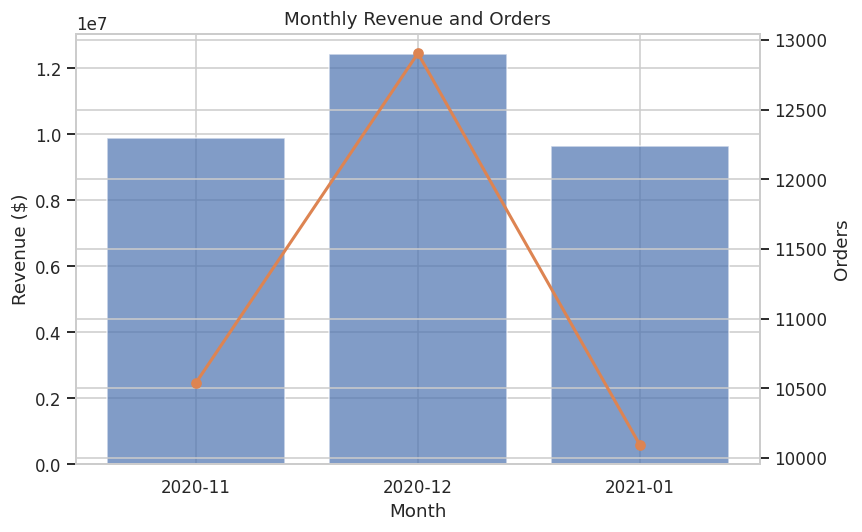

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.bar(monthly["order_month"], monthly["revenue"], color="#4C72B0", alpha=0.7, label="Revenue")
ax2.plot(monthly["order_month"], monthly["orders"], color="#DD8452", marker="o", linewidth=2, label="Orders")
ax1.set_ylabel("Revenue ($)")
ax2.set_ylabel("Orders")
ax1.set_xlabel("Month")
ax1.set_title("Monthly Revenue and Orders")
fig.tight_layout()
plt.show()


Revenue and order volume dip in **January 2021**, alongside a small drop in conversion rate
(from ~10.0% in Nov/Dec to ~8.8% in Jan) — a plausible post-holiday-season slowdown.

### 2.3 Revenue by product category

In [8]:
cat_revenue = df[df["purchased"]].groupby("product_category")["revenue"].agg(["sum", "count"]).sort_values("sum", ascending=False)
cat_revenue.columns = ["total_revenue", "orders"]
cat_revenue


,total_revenue,orders
product_category,,
Sofas & armchairs,8388254.5,4301
Chairs,6147748.8,5952
Beds,4919725.0,2926
Bookcases & shelving units,3640818.1,7630
Cabinets & cupboards,2336499.5,2318
Outdoor furniture,2142222.2,2229
Tables & desks,1790307.5,2941
Chests of drawers & drawer units,906562.5,1452
Bar furniture,735503.0,1092


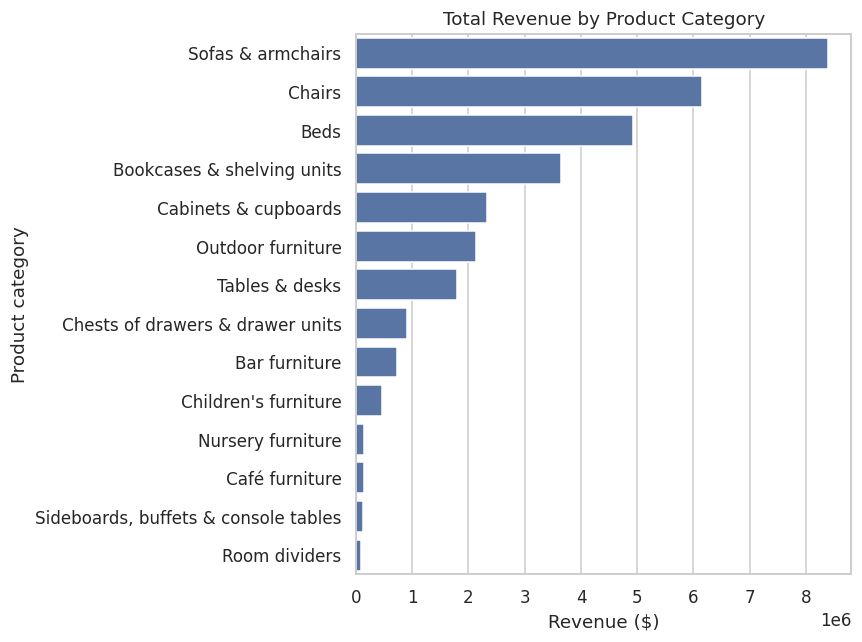

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=cat_revenue["total_revenue"], y=cat_revenue.index, ax=ax, color="#4C72B0")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Product category")
ax.set_title("Total Revenue by Product Category")
fig.tight_layout()
plt.show()


**Sofas & armchairs, Chairs, and Beds** are the top 3 revenue-generating categories, together contributing
almost 60% of total revenue despite representing a minority of orders — consistent with these being
higher-priced items.

### 2.4 Conversion by device

In [10]:
device_conv = df.groupby("device")["purchased"].agg(["mean", "count"])
device_conv.columns = ["conversion_rate", "sessions"]
device_conv


,conversion_rate,sessions
device,,
desktop,0.096376,204429
mobile,0.095529,137267
tablet,0.092114,7849


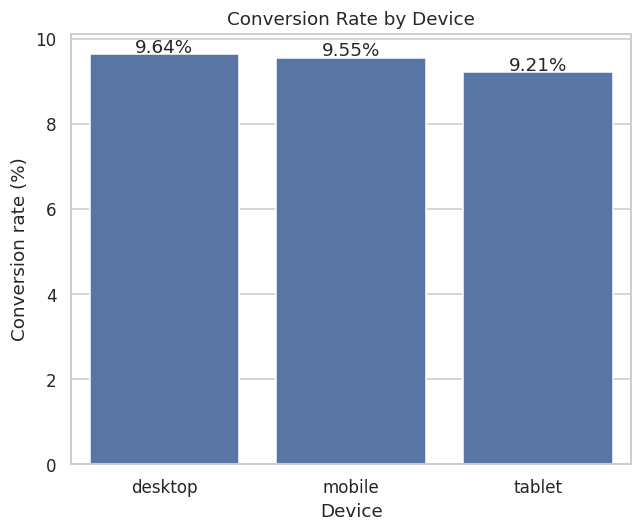

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
rate = device_conv["conversion_rate"] * 100
sns.barplot(x=rate.index, y=rate.values, ax=ax)
ax.set_ylabel("Conversion rate (%)")
ax.set_xlabel("Device")
ax.set_title("Conversion Rate by Device")
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center")
fig.tight_layout()
plt.show()


Conversion is essentially flat across devices (desktop 9.64%, mobile 9.55%, tablet 9.21%) — no device stands out.

### 2.5 Top countries by traffic

In [12]:
top_countries = df["country"].value_counts().head(10)
top_countries


country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Spain               6505
Germany             6196
China               6066
Taiwan              5879
Italy               4859
Name: count, dtype: int64

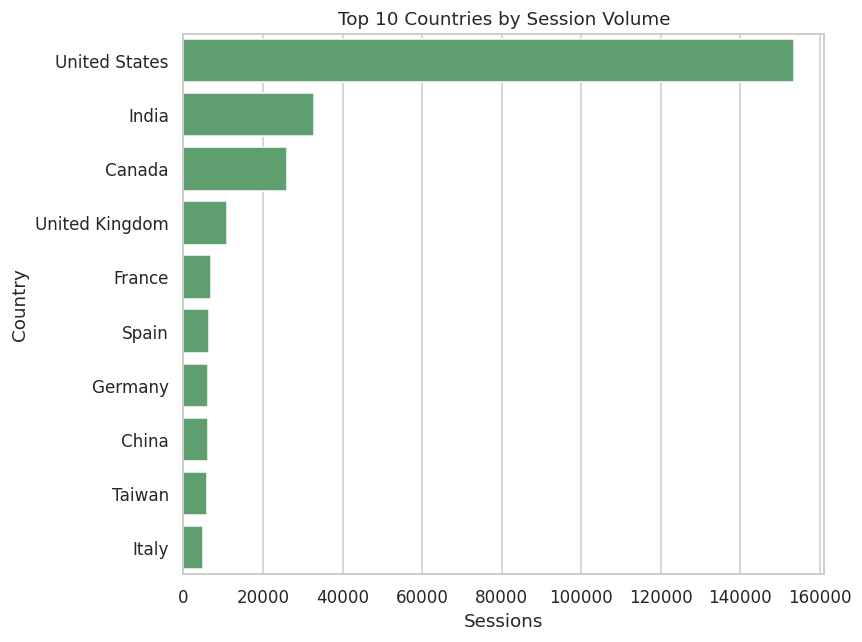

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color="#55A868")
ax.set_xlabel("Sessions")
ax.set_ylabel("Country")
ax.set_title("Top 10 Countries by Session Volume")
fig.tight_layout()
plt.show()


The **United States** dominates traffic (~44% of sessions), followed by **India** and **Canada**.

### 2.6 Traffic channel: volume vs. conversion

In [14]:
channel_perf = df.groupby("traffic_channel").agg(
    sessions=("ga_session_id", "count"),
    conversion_rate=("purchased", "mean"),
).reset_index().sort_values("sessions", ascending=False)
channel_perf["conversion_rate"] = (channel_perf["conversion_rate"] * 100).round(2)
channel_perf


,traffic_channel,sessions,conversion_rate
1,Organic Search,124425,9.58
2,Paid Search,94341,9.58
0,Direct,81382,9.58
3,Social Search,27914,9.73
4,Undefined,21483,9.58


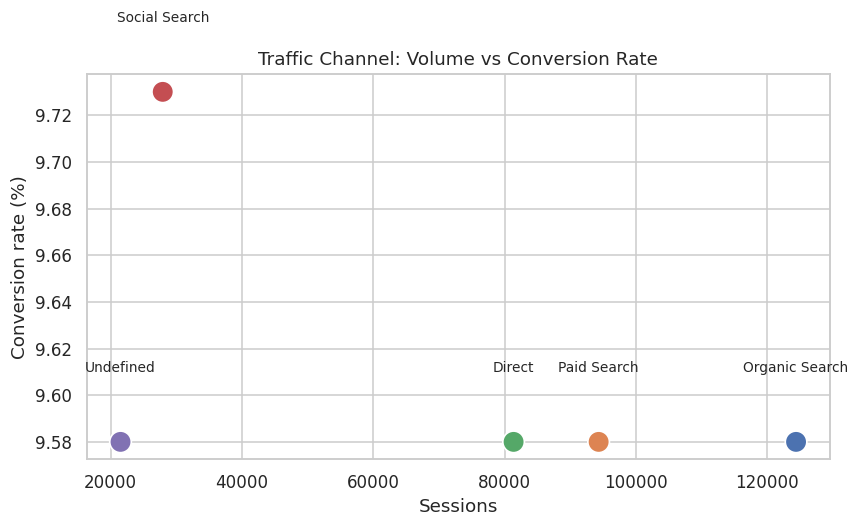

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=channel_perf, x="sessions", y="conversion_rate", s=200, hue="traffic_channel", ax=ax, legend=False)
for _, row in channel_perf.iterrows():
    ax.text(row["sessions"], row["conversion_rate"] + 0.03, row["traffic_channel"], ha="center", fontsize=9)
ax.set_xlabel("Sessions")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Traffic Channel: Volume vs Conversion Rate")
fig.tight_layout()
plt.show()


**Organic Search** brings the most volume, while **Social Search** has the (marginally) highest conversion
rate — though the spread across channels is small (9.58%–9.73%), suggesting channel alone isn't a strong
lever for conversion in this dataset.

## 3. Segment comparisons

### 3.1 Registered vs. guest users

In [16]:
reg_conv = df.groupby("is_registered")["purchased"].agg(["mean", "count"])
reg_conv.index = ["Guest", "Registered"]
reg_conv.columns = ["conversion_rate", "sessions"]
reg_conv


,conversion_rate,sessions
Guest,0.095637,321600
Registered,0.099517,27945


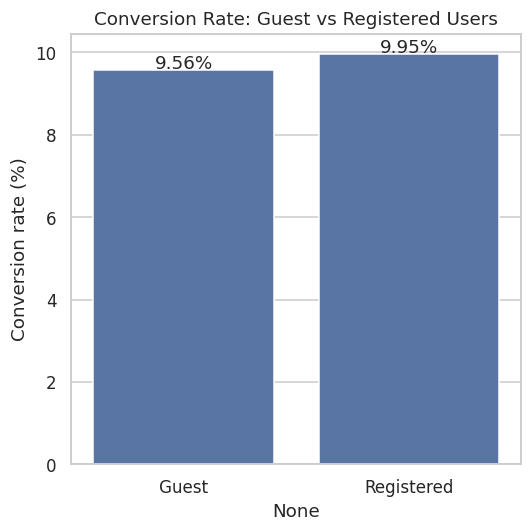

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
rate = reg_conv["conversion_rate"] * 100
sns.barplot(x=reg_conv.index, y=rate.values, ax=ax)
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion Rate: Guest vs Registered Users")
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center")
fig.tight_layout()
plt.show()


Registered users convert slightly better (9.95% vs 9.56%), but the gap is modest — registration alone isn't a major conversion driver.

### 3.2 Subscribed vs. non-subscribed

In [18]:
sub_conv = df.groupby("is_subscribed")["purchased"].agg(["mean", "count"])
sub_conv.index = ["Not subscribed", "Subscribed"]
sub_conv.columns = ["conversion_rate", "sessions"]
sub_conv


,conversion_rate,sessions
Not subscribed,0.09562,326335
Subscribed,0.10056,23210


Subscribers convert at 10.06% vs. 9.56% for non-subscribers — a small, directionally positive signal for email marketing.

## 4. Predictive modeling: can session attributes predict conversion?

As a data-science exercise, we test whether a classifier can predict `purchased` from attributes
available **before** a customer picks a product: continent, device, browser, traffic channel, and account
status (registered / subscribed / email verified). This mirrors a real question a growth team would ask:
*"Can we identify high-intent sessions in real time and prioritize them?"*

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

features = ["continent", "device", "browser", "traffic_channel", "is_registered", "is_subscribed", "email_verified"]
X = df[features].copy()
y = df["purchased"].astype(int)

cat_cols = ["continent", "device", "browser", "traffic_channel"]
bool_cols = ["is_registered", "is_subscribed", "email_verified"]
for c in bool_cols:
    X[c] = X[c].astype(int)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, probs):.3f}")
print(classification_report(y_test, preds, target_names=["No purchase", "Purchase"]))


ROC-AUC: 0.498
              precision    recall  f1-score   support

 No purchase       0.90      0.42      0.57     63201
    Purchase       0.10      0.58      0.16      6708

    accuracy                           0.44     69909
   macro avg       0.50      0.50      0.37     69909
weighted avg       0.83      0.44      0.53     69909



**Result: ROC-AUC ≈ 0.50** — essentially no better than random guessing.

This is a genuinely useful negative finding: acquisition-level attributes (device, browser, traffic channel,
geography, account status) carry almost no signal about whether a session will convert. It confirms what the
EDA already hinted at — conversion rates barely move across these dimensions (all cluster tightly around
9–10%). The implication for the business: **factors that actually drive furniture purchases likely live
on-site** (product page engagement, price sensitivity, session duration, cart behavior) rather than in who the
visitor is or how they arrived. Future data collection should prioritize on-site behavioral signals if the
goal is to predict or influence conversion.

## 5. Key takeaways

1. **Overall conversion rate is ~9.6%**, generating ~$32M in revenue over the 3-month window at a high AOV (~$953), consistent with furniture being a considered, high-ticket purchase.
2. **Sofas & armchairs, Chairs, and Beds** drive the majority of revenue despite not being the highest-volume categories — pricing, not order count, is the main revenue lever.
3. Conversion rate is **remarkably stable across device, traffic channel, and country** — no single acquisition dimension is a strong differentiator on its own.
4. **Registered and subscribed users convert modestly better** than guests/non-subscribers (~0.4–0.5 pts higher), a small but directionally useful signal for retention and email marketing.
5. A classifier built purely on acquisition-level attributes achieves **~0.50 ROC-AUC** — meaning these features have no real predictive power for conversion. Meaningful predictive signal would need on-site behavioral data (time on page, cart adds, scroll depth, etc.), which isn't present in this dataset.
6. **January 2021 shows a mild post-holiday dip** in both order volume and conversion rate relative to Nov/Dec 2020.

See the [Tableau dashboard](https://public.tableau.com/app/profile/dmytro.ruzhytskyi/viz/projectDashboard_17799941828760/Dashboard1) for an interactive exploration of these metrics.
